# Comprensión y análisis exploratorio de datos (EDA)

**Proyecto Integrador — Modelo de riesgo crediticio**

Objetivo del notebook: comprender en profundidad la base de datos histórica de
créditos (`Base_de_datos.csv`), dejar los datos con tipos y nulos
consistentes, y documentar hallazgos, reglas de validación y posibles
transformaciones/atributos derivados que se usarán en el Avance 2
(`ft_engineering.py`).

Variable objetivo: **`Pago_atiempo`** (1 = pagó a tiempo, 0 = no pagó a
tiempo).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

RANDOM_STATE = 42

## 1. Exploración inicial de datos

### 1.1 Carga y descripción general

In [2]:
df = pd.read_csv("../Base_de_datos.csv", parse_dates=["fecha_prestamo"])
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 10,763 | Columnas: 23


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [3]:
df.dtypes.to_frame("dtype")

,dtype
tipo_credito,int64
fecha_prestamo,datetime64[us]
capital_prestado,float64
plazo_meses,int64
edad_cliente,int64
tipo_laboral,str
salario_cliente,int64
total_otros_prestamos,int64
cuota_pactada,int64
puntaje,float64


### 1.2 Caracterización de las variables

| Variable | Tipo | Descripción |
|---|---|---|
| `tipo_credito` | Categórica nominal (codificada) | Código del tipo de crédito solicitado |
| `fecha_prestamo` | Fecha | Fecha de desembolso del crédito |
| `capital_prestado` | Numérica continua | Monto de capital prestado |
| `plazo_meses` | Numérica discreta | Plazo del crédito en meses |
| `edad_cliente` | Numérica discreta | Edad del cliente en años |
| `tipo_laboral` | Categórica nominal dicotómica | `Empleado` / `Independiente` |
| `salario_cliente` | Numérica continua | Salario declarado del cliente |
| `total_otros_prestamos` | Numérica continua | Saldo de otros préstamos vigentes |
| `cuota_pactada` | Numérica continua | Cuota mensual pactada del crédito |
| `puntaje` | Numérica continua | Score interno del cliente (ver hallazgo de correlación en la sección 3) |
| `puntaje_datacredito` | Numérica continua | Score de la central de riesgo (Datacrédito) |
| `cant_creditosvigentes` | Numérica discreta | Cantidad de créditos vigentes |
| `huella_consulta` | Numérica discreta | Cantidad de consultas recientes a central de riesgo |
| `saldo_mora` | Numérica continua | Saldo en mora |
| `saldo_total` | Numérica continua | Saldo total de la deuda |
| `saldo_principal` | Numérica continua | Saldo de capital |
| `saldo_mora_codeudor` | Numérica continua | Saldo en mora del codeudor |
| `creditos_sectorFinanciero` | Numérica discreta | Créditos vigentes en el sector financiero |
| `creditos_sectorCooperativo` | Numérica discreta | Créditos vigentes en el sector cooperativo |
| `creditos_sectorReal` | Numérica discreta | Créditos vigentes en el sector real |
| `promedio_ingresos_datacredito` | Numérica continua | Ingresos promedio reportados a la central de riesgo |
| `tendencia_ingresos` | Categórica nominal politómica | `Creciente` / `Estable` / `Decreciente` |
| `Pago_atiempo` | Categórica dicotómica (target) | 1 = pagó a tiempo, 0 = no pagó a tiempo |

No se identifican variables ordinales explícitas; `tipo_credito` es nominal
aunque esté codificada como entero.

### 1.3 Revisión de nulos

In [4]:
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
null_summary = pd.DataFrame({"nulos": nulls, "% nulos": nulls_pct})
null_summary = null_summary[null_summary["nulos"] > 0].sort_values("% nulos", ascending=False)
null_summary

,nulos,% nulos
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


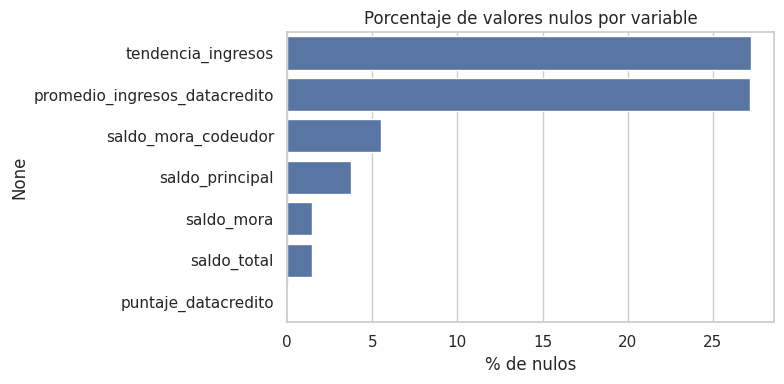

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=null_summary["% nulos"], y=null_summary.index, ax=ax, color="#4C72B0")
ax.set_xlabel("% de nulos")
ax.set_title("Porcentaje de valores nulos por variable")
plt.tight_layout()
plt.show()

`tendencia_ingresos` concentra la mayor proporción de nulos (~27%), seguida de
`promedio_ingresos_datacredito` (~27%, prácticamente los mismos registros —
ambas provienen de la consulta a la central de riesgo). Las variables de
saldo (`saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor`)
tienen nulos menores al 6%, consistentes con clientes sin crédito previo.

### 1.4 Unificación de valores nulos

In [6]:
# `tendencia_ingresos` debería ser una variable categórica con 3 valores válidos.
# Se detectan valores numéricos "sueltos" (probablemente un error de origen /
# corrimiento de columna en la fuente) que no son categorías válidas.
valores_validos = {"Creciente", "Estable", "Decreciente"}
print("Valores únicos antes de limpiar:", df["tendencia_ingresos"].nunique(dropna=True))

valores_invalidos = df.loc[
    df["tendencia_ingresos"].notna() & ~df["tendencia_ingresos"].astype(str).isin(valores_validos),
    "tendencia_ingresos",
]
print(f"Registros con valor no válido en tendencia_ingresos: {len(valores_invalidos)}")
valores_invalidos.head(10)

Valores únicos antes de limpiar: 46
Registros con valor no válido en tendencia_ingresos: 58


157        8315
168           0
440      158042
486        3978
705        9147
1185       8315
1188     168750
1898     -28589
2027       8315
2038    1000000
Name: tendencia_ingresos, dtype: str

In [7]:
# Se unifican como nulos (NaN) los valores que no correspondan a una categoría válida
df.loc[~df["tendencia_ingresos"].isin(valores_validos), "tendencia_ingresos"] = np.nan

nulls_pct_after = (df["tendencia_ingresos"].isnull().sum() / len(df) * 100).round(2)
print(f"% nulos en tendencia_ingresos tras unificar: {nulls_pct_after}%")
df["tendencia_ingresos"].value_counts(dropna=False)

% nulos en tendencia_ingresos tras unificar: 27.78%


tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64

El resto de columnas ya utiliza `NaN` de forma consistente (no se detectaron
otras representaciones de nulo como `-1`, `"N/A"`, `"sin dato"` o cadenas
vacías).

### 1.5 Variables irrelevantes / redundantes

In [8]:
# Verificación de consistencia: saldo_total vs (saldo_principal + saldo_mora)
sub = df[["saldo_total", "saldo_principal", "saldo_mora"]].dropna()
diff = (sub["saldo_total"] - (sub["saldo_principal"] + sub["saldo_mora"])).abs()
print("Diferencia absoluta saldo_total vs (saldo_principal + saldo_mora):")
print(diff.describe())

Diferencia absoluta saldo_total vs (saldo_principal + saldo_mora):
count    1.035800e+04
mean     6.702021e+03
std      7.318797e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.617429e+06
dtype: float64


La mediana de la diferencia es 0 (en más de la mitad de los casos
`saldo_total = saldo_principal + saldo_mora`), pero existen inconsistencias en
otros registros (diferencia máxima de varios millones), por lo que **no se
puede tratar `saldo_total` como una columna redundante y eliminarla**: se
conserva junto con `saldo_principal` y `saldo_mora`, y se deja como regla de
validación para la etapa de ingeniería de características.

No se identifican columnas puramente identificadoras (tipo *id*) ni columnas
constantes. Se conservan todas las variables; sí se marca `puntaje` como una
variable a **revisar con especial cuidado** por el hallazgo de la sección 3
(posible fuga de información / *leakage*).

### 1.6 Corrección de tipos de datos

In [9]:
df["tipo_credito"] = df["tipo_credito"].astype("category")
df["tipo_laboral"] = df["tipo_laboral"].astype("category")
df["tendencia_ingresos"] = df["tendencia_ingresos"].astype("category")
df["Pago_atiempo"] = df["Pago_atiempo"].astype(int)  # se mantiene 0/1 para el cálculo de métricas

df.dtypes.to_frame("dtype")

,dtype
tipo_credito,category
fecha_prestamo,datetime64[us]
capital_prestado,float64
plazo_meses,int64
edad_cliente,int64
tipo_laboral,category
salario_cliente,int64
total_otros_prestamos,int64
cuota_pactada,int64
puntaje,float64


## 2. Exploración de datos y descripción (EDA)

### 2.1 Análisis univariable

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop("Pago_atiempo").tolist()
cat_cols = ["tipo_credito", "tipo_laboral", "tendencia_ingresos"]

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
capital_prestado,10763.0,2.434315e+06,1.909643e+06,360000.00000,1.224831e+06,1.921920e+06,3.084840e+06,4.144415e+07
plazo_meses,10763.0,1.057558e+01,6.632082e+00,2.00000,6.000000e+00,1.000000e+01,1.200000e+01,9.000000e+01
edad_cliente,10763.0,4.394862e+01,1.506088e+01,19.00000,3.300000e+01,4.200000e+01,5.300000e+01,1.230000e+02
salario_cliente,10763.0,1.721643e+07,3.554767e+08,0.00000,2.000000e+06,3.000000e+06,4.875808e+06,2.200000e+10
total_otros_prestamos,10763.0,6.238870e+06,1.184183e+08,0.00000,5.000000e+05,1.000000e+06,2.000000e+06,6.787675e+09
cuota_pactada,10763.0,2.436174e+05,2.104937e+05,23944.00000,1.210415e+05,1.828630e+05,2.878335e+05,3.816752e+06
puntaje,10763.0,9.117004e+01,1.646544e+01,-38.00999,9.522779e+01,9.522779e+01,9.522779e+01,9.522779e+01
puntaje_datacredito,10757.0,7.807908e+02,1.048780e+02,-7.00000,7.570000e+02,7.910000e+02,8.250000e+02,9.990000e+02
cant_creditosvigentes,10763.0,5.726749e+00,3.977162e+00,0.00000,3.000000e+00,5.000000e+00,8.000000e+00,6.200000e+01
huella_consulta,10763.0,4.228561e+00,3.064683e+00,0.00000,2.000000e+00,4.000000e+00,6.000000e+00,2.900000e+01


**Medidas de dispersión adicionales** (rango, IQR, varianza, asimetría y
curtosis) para las variables numéricas continuas más relevantes:

In [11]:
cont_vars = ["capital_prestado", "salario_cliente", "total_otros_prestamos",
             "cuota_pactada", "puntaje", "puntaje_datacredito", "edad_cliente"]

disp = pd.DataFrame({
    "rango": df[cont_vars].max() - df[cont_vars].min(),
    "IQR": df[cont_vars].quantile(0.75) - df[cont_vars].quantile(0.25),
    "varianza": df[cont_vars].var(),
    "desv_std": df[cont_vars].std(),
    "skewness": df[cont_vars].skew(),
    "kurtosis": df[cont_vars].kurt(),
})
disp

,rango,IQR,varianza,desv_std,skewness,kurtosis
capital_prestado,4.108415e+07,1860009.0,3.646735e+12,1.909643e+06,3.723884,35.318092
salario_cliente,2.200000e+10,2875808.0,1.263637e+17,3.554767e+08,43.776664,2211.230120
total_otros_prestamos,6.787675e+09,1500000.0,1.402290e+16,1.184183e+08,38.463886,1719.280871
cuota_pactada,3.792808e+06,166792.0,4.430760e+10,2.104937e+05,3.793301,26.650757
puntaje,1.332378e+02,0.0,2.711108e+02,1.646544e+01,-4.865607,24.081011
puntaje_datacredito,1.006000e+03,68.0,1.099940e+04,1.048780e+02,-5.644513,39.437798
edad_cliente,1.040000e+02,20.0,2.268300e+02,1.506088e+01,1.934399,7.868936


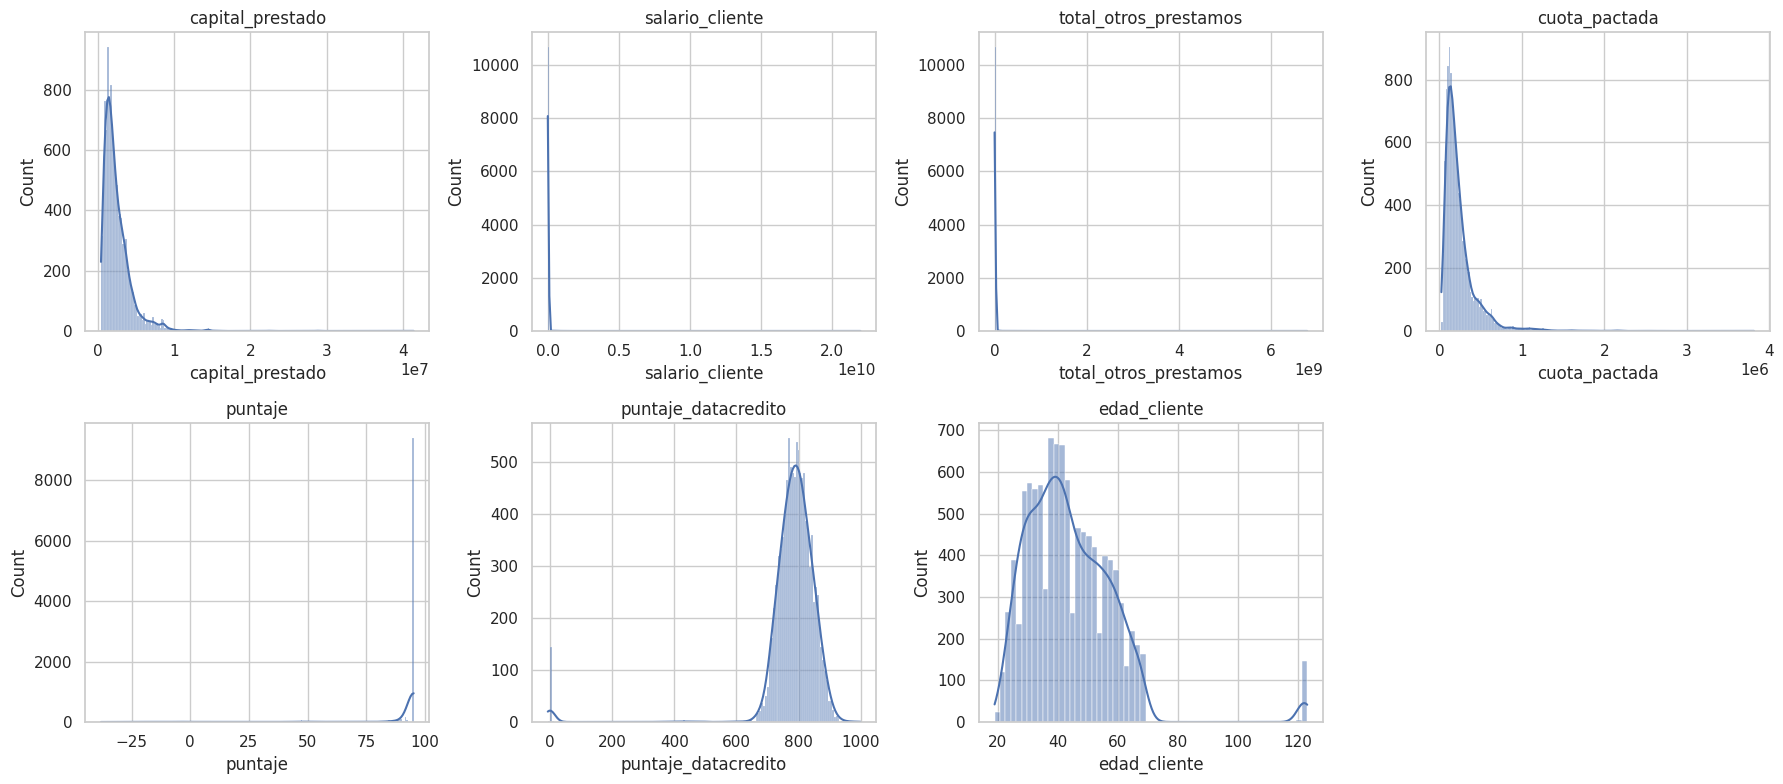

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, cont_vars):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
for ax in axes.flat[len(cont_vars):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

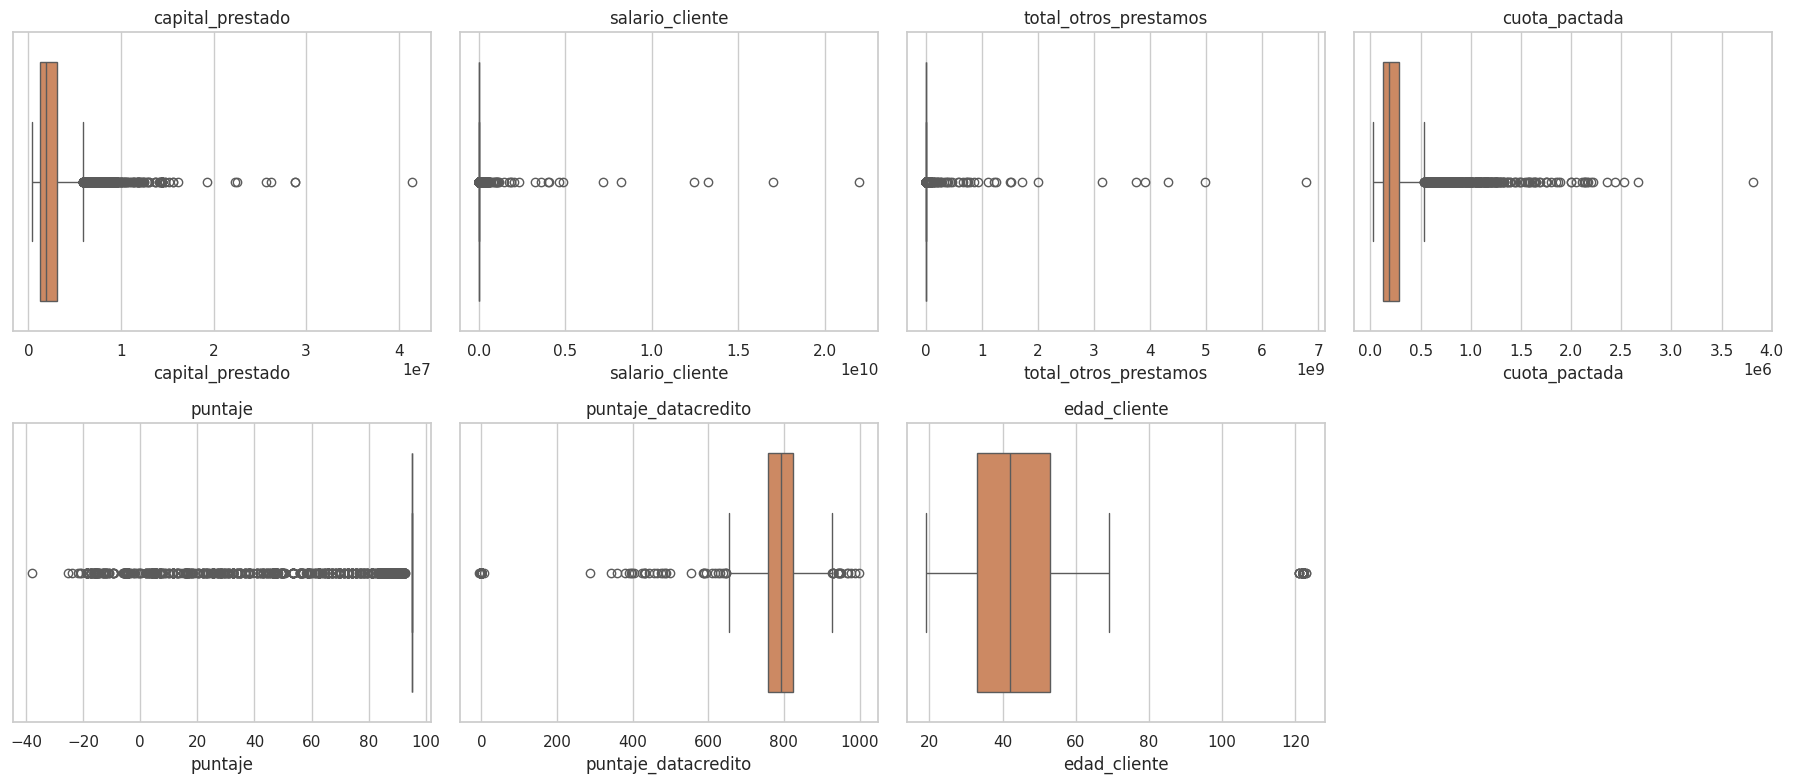

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, cont_vars):
    sns.boxplot(x=df[col], ax=ax, color="#DD8452")
    ax.set_title(col)
for ax in axes.flat[len(cont_vars):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Hallazgos univariables clave:**

- `salario_cliente` y `total_otros_prestamos` presentan una asimetría y
  curtosis extremadamente altas, con valores máximos (miles de millones) muy
  por encima de la mediana — casi con certeza son **errores de captura**
  (posible desplazamiento de decimales o de unidades) y no ingresos reales.
- `edad_cliente` llega hasta 123 años, un valor no plausible que debe tratarse
  como outlier / error de captura.
- `capital_prestado` y `cuota_pactada` muestran una distribución con cola a la
  derecha (créditos de alto monto), consistente con un producto financiero
  típico.
- `puntaje` y `puntaje_datacredito` tienen distribuciones razonablemente
  simétricas dentro de rangos acotados (0–100 y ~300–950 respectivamente),
  compatibles con scores estandarizados.

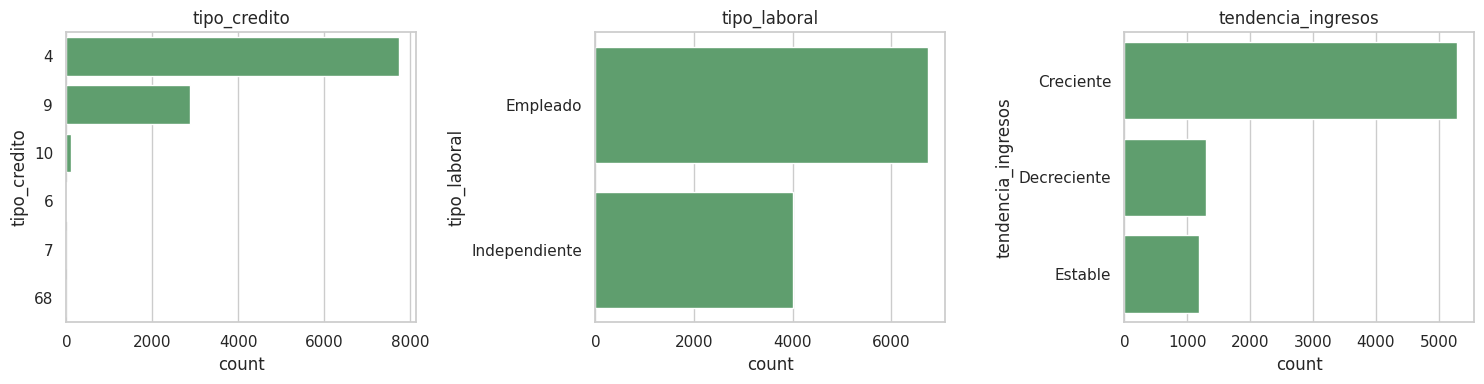


--- tipo_credito ---
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64

--- tipo_laboral ---
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

--- tendencia_ingresos ---
tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, color="#55A868")
    ax.set_title(col)
plt.tight_layout()
plt.show()

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

`tipo_laboral` está balanceada entre `Empleado` (~63%) e `Independiente`
(~37%). `tendencia_ingresos` es mayoritariamente `Creciente`. `tipo_credito`
está fuertemente concentrada en dos códigos (4 y 9); el código `68` aparece
una sola vez — se trata como **categoría rara** a agrupar en `ft_engineering.py`
(p. ej. bajo una categoría "otros").

Pago_atiempo
1    0.952523
0    0.047477
Name: proporción, dtype: float64


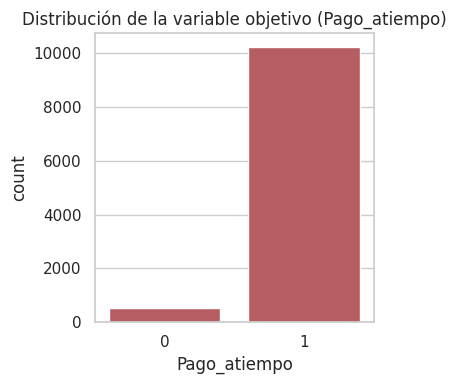

In [15]:
target_dist = df["Pago_atiempo"].value_counts(normalize=True).rename("proporción")
print(target_dist)

fig, ax = plt.subplots(figsize=(4, 4))
sns.countplot(x=df["Pago_atiempo"], ax=ax, color="#C44E52")
ax.set_title("Distribución de la variable objetivo (Pago_atiempo)")
plt.tight_layout()
plt.show()

**La variable objetivo está fuertemente desbalanceada**: ~95.3% de los
créditos se pagaron a tiempo (`1`) frente a ~4.7% que no (`0`). Este
desbalance debe tenerse en cuenta en el Avance 2 (estrategias como *class
weights*, *resampling* o métricas robustas al desbalance como recall, F1 o
ROC-AUC en lugar de accuracy).

### 2.2 Análisis bivariable (respecto a la variable objetivo)

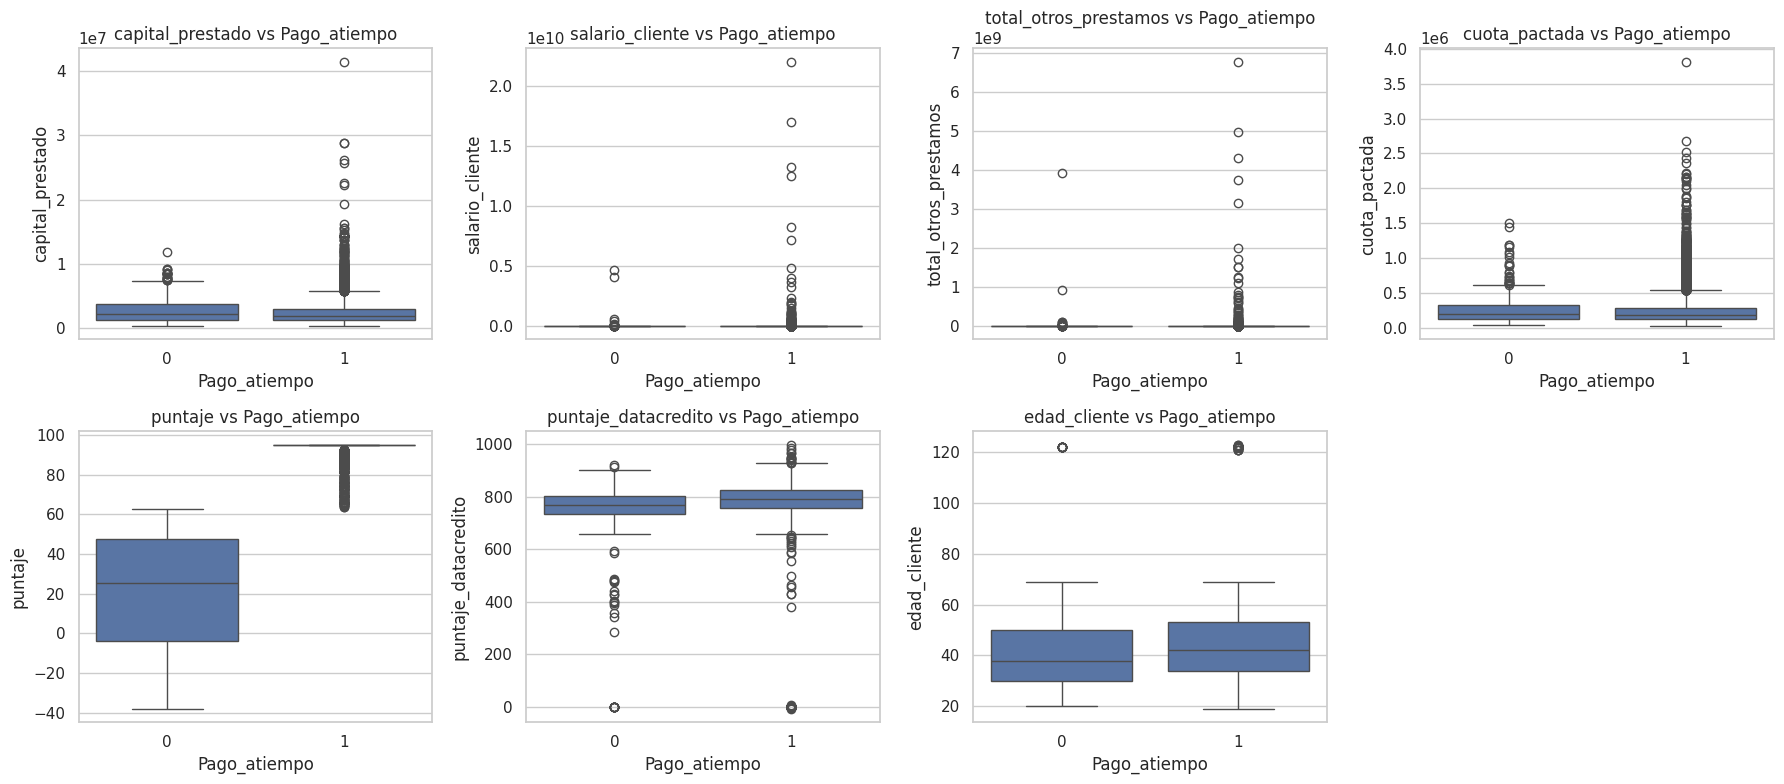

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, cont_vars):
    sns.boxplot(x=df["Pago_atiempo"], y=df[col], ax=ax)
    ax.set_title(f"{col} vs Pago_atiempo")
for ax in axes.flat[len(cont_vars):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**`puntaje` separa casi perfectamente las dos clases** (los créditos que no
pagan a tiempo tienen un `puntaje` claramente más bajo), mientras que el
resto de variables numéricas muestran distribuciones muy similares entre
ambas clases, con poca separación visual. Esto es consistente con el
hallazgo de correlación de la sección 3.

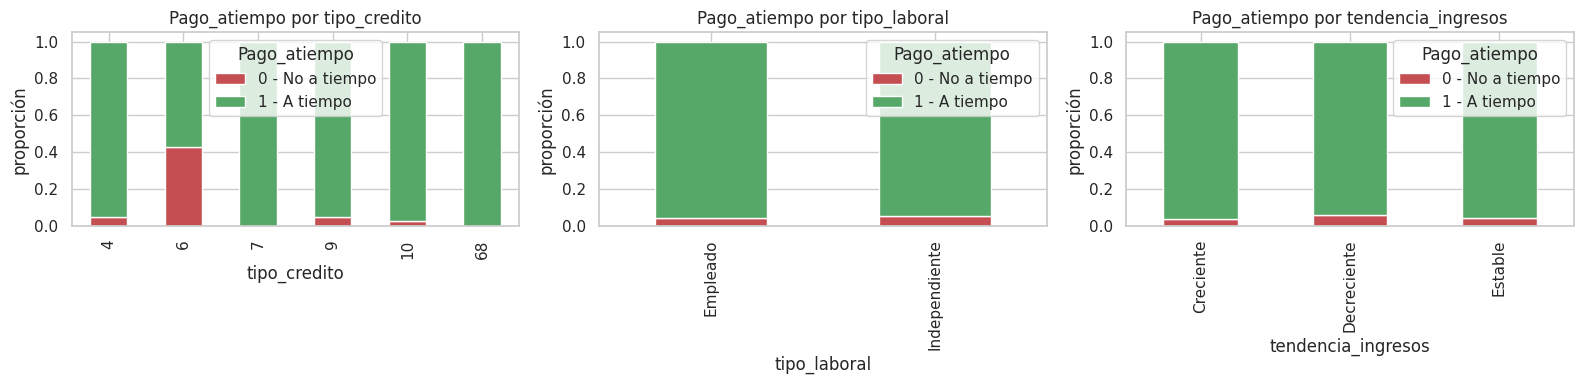

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    prop = pd.crosstab(df[col], df["Pago_atiempo"], normalize="index")
    prop.plot(kind="bar", stacked=True, ax=ax, color=["#C44E52", "#55A868"])
    ax.set_title(f"Pago_atiempo por {col}")
    ax.set_ylabel("proporción")
    ax.legend(title="Pago_atiempo", labels=["0 - No a tiempo", "1 - A tiempo"])
plt.tight_layout()
plt.show()

No se observan diferencias grandes en la tasa de pago a tiempo entre
categorías de `tipo_laboral` ni `tendencia_ingresos`; `tipo_credito` sí
muestra algunas diferencias entre códigos, aunque con conteos muy desiguales
(el código `68`, con un solo registro, no es representativo).

### 2.3 Análisis multivariable

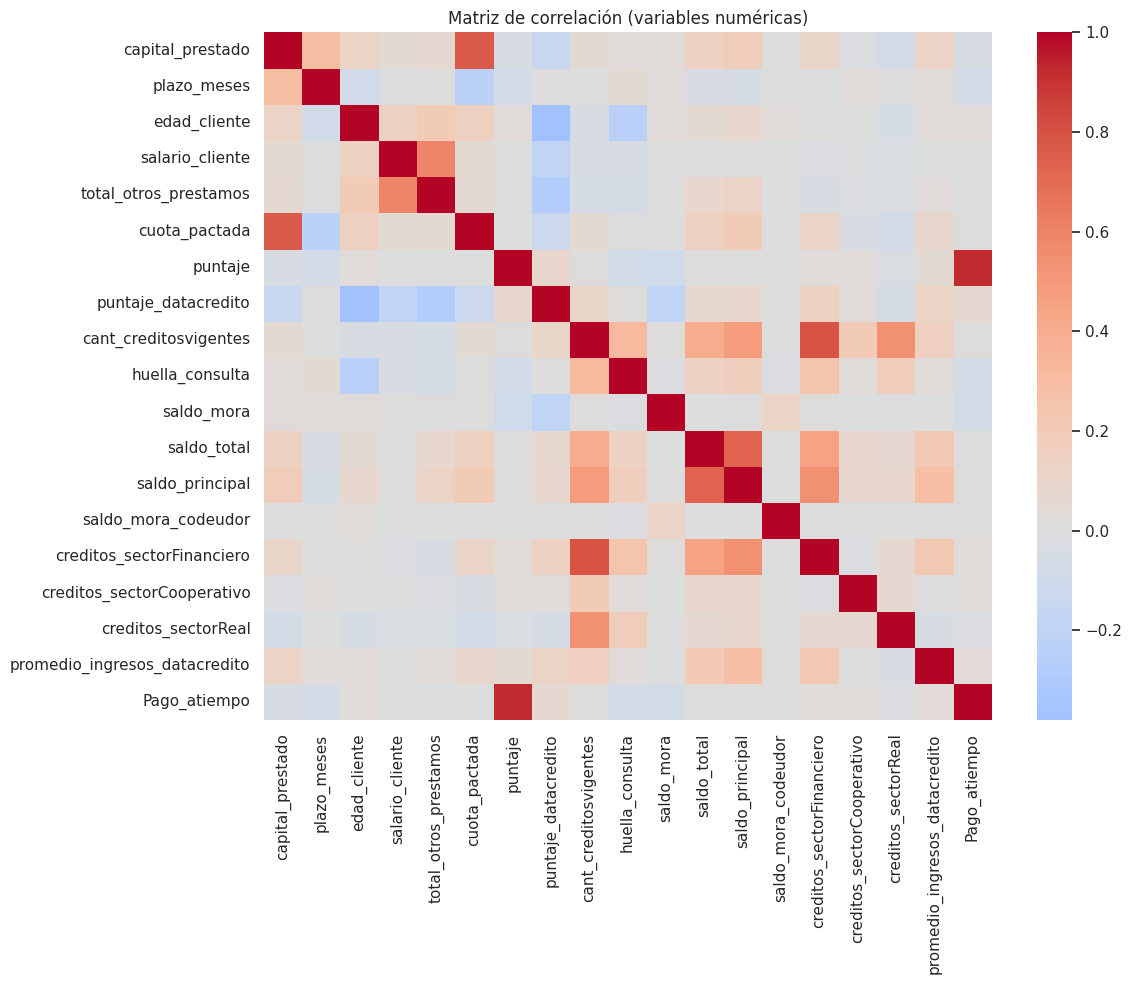

puntaje                          0.923134
puntaje_datacredito              0.067882
promedio_ingresos_datacredito    0.039867
edad_cliente                     0.032252
creditos_sectorFinanciero        0.021390
creditos_sectorCooperativo       0.021267
saldo_total                      0.014364
saldo_principal                  0.011473
cant_creditosvigentes            0.008829
saldo_mora_codeudor              0.002631
salario_cliente                 -0.003981
total_otros_prestamos           -0.010041
cuota_pactada                   -0.011814
creditos_sectorReal             -0.023306
capital_prestado                -0.040624
plazo_meses                     -0.063105
saldo_mora                      -0.073458
huella_consulta                 -0.073737
Name: Pago_atiempo, dtype: float64

In [18]:
corr = df[num_cols + ["Pago_atiempo"]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()

corr["Pago_atiempo"].drop("Pago_atiempo").sort_values(ascending=False)

**Hallazgo principal:** `puntaje` tiene una correlación de **~0.92** con
`Pago_atiempo`, muy por encima de cualquier otra variable (la siguiente,
`puntaje_datacredito`, apenas llega a ~0.07). Una correlación tan alta con el
target es una señal de alerta de **posible fuga de información (data
leakage)**: hay que validar con el negocio si `puntaje` es un score
disponible *antes* de otorgar el crédito (features legítimo) o si en
realidad se calcula *después* de conocer el resultado del pago (en cuyo caso
no debería usarse como feature, o debe usarse con mucho cuidado y
documentarse explícitamente).

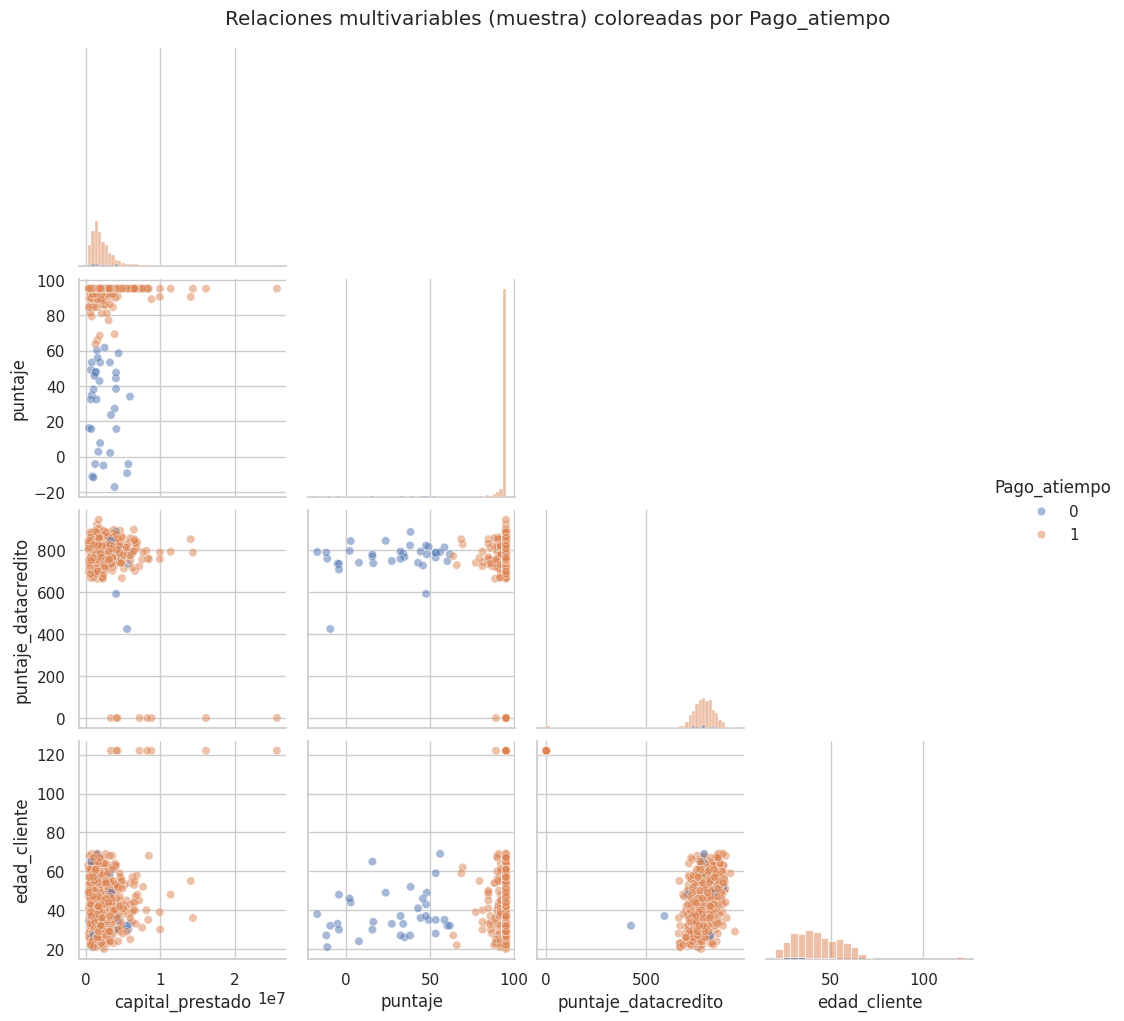

In [19]:
sample = df.sample(min(800, len(df)), random_state=RANDOM_STATE)
pairplot_vars = ["capital_prestado", "puntaje", "puntaje_datacredito", "edad_cliente", "Pago_atiempo"]
sns.pairplot(sample[pairplot_vars], hue="Pago_atiempo", diag_kind="hist", corner=True, plot_kws={"alpha": 0.5})
plt.suptitle("Relaciones multivariables (muestra) coloreadas por Pago_atiempo", y=1.02)
plt.show()

In [20]:
pd.crosstab(df["tipo_laboral"], df["tendencia_ingresos"], normalize="index").round(3)

tendencia_ingresos,Creciente,Decreciente,Estable
tipo_laboral,,,
Empleado,0.708,0.173,0.119
Independiente,0.618,0.151,0.231


No se observa una relación fuerte entre `tipo_laboral` y `tendencia_ingresos`
(las proporciones son similares entre `Empleado` e `Independiente`).

## 3. Hallazgos y reglas de validación de datos

**Hallazgos principales:**

1. **Posible fuga de información en `puntaje`** (correlación ~0.92 con el
   target). Debe validarse con el equipo de negocio antes de usarla como
   feature en el Avance 2; de no poder confirmarse su disponibilidad al
   momento de la originación del crédito, debería excluirse del modelamiento.
2. **Desbalance de clases**: ~95.3% / 4.7% en `Pago_atiempo`. Se recomienda
   usar recall, F1 y ROC-AUC (no accuracy) y considerar *class_weight* o
   técnicas de remuestreo en el Avance 2.
3. **Outliers extremos de captura** en `salario_cliente`,
   `total_otros_prestamos` (valores hasta miles de millones) y `edad_cliente`
   (hasta 123 años). Deben acotarse (winsorización / capping) o filtrarse en
   `ft_engineering.py`.
4. **Valores no categóricos en `tendencia_ingresos`** (ruido numérico),
   unificados como nulos en este notebook. Junto con
   `promedio_ingresos_datacredito`, tienen ~27% de nulos — evaluar imputación
   o una categoría explícita "sin información" en el Avance 2.
5. **Categoría rara en `tipo_credito`** (código `68`, un solo registro) — a
   agrupar bajo "otros" para evitar sobreajuste por categorías con muy pocas
   observaciones.
6. **Inconsistencias menores** entre `saldo_total` y
   `saldo_principal + saldo_mora` en un subconjunto de registros — documentar
   como regla de validación, no eliminar las columnas.

**Reglas de validación propuestas para etapas posteriores del pipeline:**

- `edad_cliente` debe estar en un rango plausible (p. ej. 18–90 años).
- `salario_cliente` y `total_otros_prestamos` deben acotarse a percentiles
  razonables (p. ej. capping en el percentil 99) antes de entrenar.
- `tendencia_ingresos` solo debe tomar los valores `Creciente`, `Estable`,
  `Decreciente` o nulo.
- `Pago_atiempo` debe ser binaria (0/1), sin nulos.
- `tipo_credito` con frecuencia menor a un umbral (p. ej. < 10 registros) se
  agrupa en la categoría "otros".

## 4. Transformaciones y atributos derivados propuestos

Para el Avance 2 (`ft_engineering.py`) se proponen las siguientes
transformaciones y variables derivadas:

- **Relación cuota/salario** (`cuota_pactada / salario_cliente`): aproxima el
  nivel de endeudamiento del cliente respecto a su ingreso.
- **Relación deuda total/salario** (`total_otros_prestamos / salario_cliente`).
- **Antigüedad del crédito** en días/meses desde `fecha_prestamo` hasta la
  fecha de análisis.
- **Bandera de mora** (`saldo_mora > 0`) como variable binaria adicional.
- **Transformación logarítmica** (`log1p`) para las variables monetarias con
  alta asimetría (`capital_prestado`, `salario_cliente`,
  `total_otros_prestamos`, `cuota_pactada`), una vez tratados los outliers.
- **Agrupación de categorías raras** en `tipo_credito` ("otros").
- **Imputación explícita** de `tendencia_ingresos` (categoría "sin
  información") y de las variables de saldo con nulos (p. ej. 0, asumiendo
  ausencia de crédito previo, a validar con negocio).
- **Bucketización de edad** (`edad_cliente`) en rangos etarios, útil para
  modelos lineales o para reglas de negocio.

> **Nota:** dado el hallazgo de la sección 3, `puntaje` se documenta pero se
> recomienda tratarlo como variable de alto riesgo de *leakage*: en el
> Avance 2 se entrenará al menos una versión del modelo sin esta variable
> para comparar el desempeño y confirmar si la fuga de información es real.